Dataset Loaded Successfully
Total Samples: 374
Total Features: 23

Step 1/2: Finding feature importance...
Done!

Step 2/2: Selecting best number of features (Please wait around 5-10 seconds)...
  -> 1 Features = Accuracy: 0.7138
  -> 2 Features = Accuracy: 0.8984
  -> 3 Features = Accuracy: 0.9011
  -> 4 Features = Accuracy: 0.9010
  -> 5 Features = Accuracy: 0.9090
  -> 6 Features = Accuracy: 0.9090
  -> 7 Features = Accuracy: 0.9090
  -> 8 Features = Accuracy: 0.9117
  -> 9 Features = Accuracy: 0.9145
  -> 10 Features = Accuracy: 0.9117
  -> 11 Features = Accuracy: 0.9117
  -> 12 Features = Accuracy: 0.9117
  -> 13 Features = Accuracy: 0.9091
  -> 14 Features = Accuracy: 0.9118
  -> 15 Features = Accuracy: 0.9118
  -> 16 Features = Accuracy: 0.9118
  -> 17 Features = Accuracy: 0.9118
  -> 18 Features = Accuracy: 0.9118
  -> 19 Features = Accuracy: 0.9118
  -> 20 Features = Accuracy: 0.9118
  -> 21 Features = Accuracy: 0.9118
  -> 22 Features = Accuracy: 0.9118
  -> 23 Features = Acc

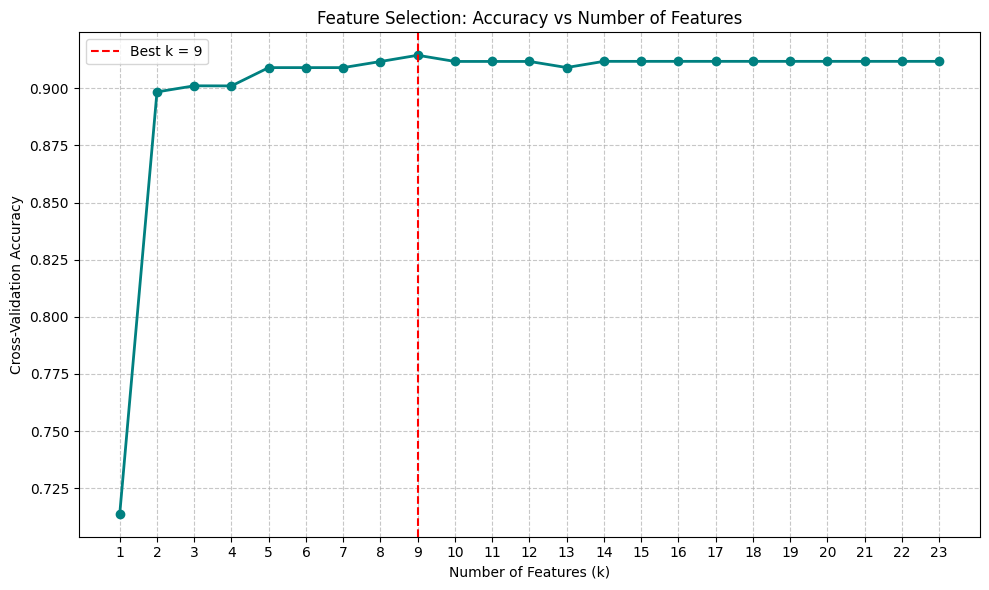

In [1]:
# ============================================
# Feature Selection: Safe & Fast Mode (Anti-Freeze)
# ============================================

import os
os.environ['OMP_NUM_THREADS'] = '1'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. Load Dataset
# ============================================
df = pd.read_csv('https://raw.githubusercontent.com/ThaLovelace/CS372_Mini-Project-1/refs/heads/main/Data/cleaned_sleep_data.csv', keep_default_na=False)

X = df.drop('Sleep Disorder', axis=1)
y = df['Sleep Disorder']

le = LabelEncoder()
y = pd.Series(le.fit_transform(y))

print("======================================")
print("Dataset Loaded Successfully")
print(f"Total Samples: {X.shape[0]}")
print(f"Total Features: {X.shape[1]}")
print("======================================\n")

# ============================================
# 2. Determine Feature Importance
# ============================================
print("Step 1/2: Finding feature importance...")
# ใช้ n_estimators=50 และ n_jobs=1 เพื่อความเร็วและเสถียรภาพ
xgb = XGBClassifier(n_estimators=50, max_depth=3, random_state=42, n_jobs=1)
xgb.fit(X, y)

importances = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
sorted_features = importances.index.tolist()
print("Done!\n")

# ============================================
# 3. Fast Feature Selection
# ============================================
print("Step 2/2: Selecting best number of features (Please wait around 5-10 seconds)...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
k_range = range(1, len(sorted_features) + 1)
cv_scores = []

for k in k_range:
    X_subset = X[sorted_features[:k]]
    fold_acc = []
    
    for train_idx, val_idx in cv.split(X_subset, y):
        X_tr, X_va = X_subset.iloc[train_idx], X_subset.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
        
        model = XGBClassifier(n_estimators=20, max_depth=3, random_state=42, n_jobs=1)
        model.fit(X_tr, y_tr)
        preds = model.predict(X_va)
        fold_acc.append(accuracy_score(y_va, preds))
        
    mean_acc = np.mean(fold_acc)
    cv_scores.append(mean_acc)
    print(f"  -> {k} Features = Accuracy: {mean_acc:.4f}")

best_k = k_range[np.argmax(cv_scores)]
best_score = max(cv_scores)

print("\n======================================")
print("Feature Selection Results")
print("======================================")
print(f"Recommended number of features (Best k): {best_k}")
print(f"Best Cross-Validation Accuracy: {best_score:.4f}")

# ============================================
# 4. Plotting
# ============================================
plt.figure(figsize=(10, 6))
plt.plot(k_range, cv_scores, marker='o', linestyle='-', color='teal', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best k = {best_k}')

plt.title('Feature Selection: Accuracy vs Number of Features')
plt.xlabel('Number of Features (k)')
plt.ylabel('Cross-Validation Accuracy')
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()